# SVI Calibration of the SPY Implied Volatility Smile

This project calibrates the raw SVI model to SPY option-implied volatilities for a single expiry.

The workflow includes cleaning option-chain data, constructing an out-of-the-money implied-volatility smile, estimating the forward price using put-call parity, transforming strikes into log-moneyness, calibrating SVI using constrained nonlinear least squares, and evaluating the fit using residual diagnostics.

## 1. Load and Inspect SPY Options Data

The option-chain snapshot contains call and put quotes across multiple strikes and expiries. The first rows of the CSV contain metadata, so they are skipped when loading the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "spy_quotedata.csv",
    skiprows=3
)

df.head()

,Expiration Date,Calls,Last Sale,Net,Bid,Ask,Volume,IV,Delta,Gamma,...,Puts,Last Sale.1,Net.1,Bid.1,Ask.1,Volume.1,IV.1,Delta.1,Gamma.1,Open Interest.1
0,Fri Dec 18 2026,SPY261218C00150000,596.00,0.0,610.53,613.88,0,1.1825,1.0000,0.0,...,SPY261218P00150000,0.02,0.0,0.01,0.02,0,0.8986,-0.0003,0.0,32487
1,Fri Dec 18 2026,SPY261218C00200000,566.90,0.0,560.89,564.20,0,0.9681,0.9992,0.0,...,SPY261218P00200000,0.04,0.0,0.04,0.05,0,0.8069,-0.0006,0.0,31905
2,Fri Dec 18 2026,SPY261218C00210000,538.28,0.0,551.02,554.37,0,0.9339,0.9991,0.0,...,SPY261218P00210000,0.05,0.0,0.05,0.06,0,0.7913,-0.0006,0.0,4882
3,Fri Dec 18 2026,SPY261218C00220000,515.90,0.0,541.15,544.50,0,0.9028,0.9990,0.0,...,SPY261218P00220000,0.07,0.0,0.05,0.06,0,0.7637,-0.0007,0.0,2478
4,Fri Dec 18 2026,SPY261218C00230000,509.19,0.0,531.29,534.63,0,0.8732,0.9989,0.0,...,SPY261218P00230000,0.07,0.0,0.06,0.07,0,0.7482,-0.0008,0.0,8359


In [3]:
df.shape

(339, 22)

In [4]:
df.columns

Index(['Expiration Date', 'Calls', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
       'IV', 'Delta', 'Gamma', 'Open Interest', 'Strike', 'Puts',
       'Last Sale.1', 'Net.1', 'Bid.1', 'Ask.1', 'Volume.1', 'IV.1', 'Delta.1',
       'Gamma.1', 'Open Interest.1'],
      dtype='object')

In [5]:
df[
    ["Strike", "Bid", "Ask", "IV",
     "Bid.1", "Ask.1", "IV.1"]
].head(20)

,Strike,Bid,Ask,IV,Bid.1,Ask.1,IV.1
0,150.0,610.53,613.88,1.1825,0.01,0.02,0.8986
1,200.0,560.89,564.20,0.9681,0.04,0.05,0.8069
2,210.0,551.02,554.37,0.9339,0.05,0.06,0.7913
3,220.0,541.15,544.50,0.9028,0.05,0.06,0.7637
4,230.0,531.29,534.63,0.8732,0.06,0.07,0.7482
5,240.0,521.42,524.74,0.8445,0.07,0.08,0.7316
6,245.0,516.49,519.84,0.8298,0.08,0.09,0.7272
7,250.0,511.55,514.90,0.8155,0.08,0.09,0.7148
8,255.0,506.62,509.97,0.8028,0.09,0.10,0.7097
9,260.0,501.69,505.04,0.7904,0.09,0.10,0.6973


## 2. Filter the Option Chain

The analysis focuses on strikes between 650 and 850 around the SPY spot price. Mid prices and bid-ask spreads are calculated to assess quote quality, and observations with invalid bid or ask prices are removed.

In [6]:
spot = 761.95

filtered = df[
    (df["Strike"] >= 650) &
    (df["Strike"] <= 850)
].copy()

filtered.shape

(142, 22)

In [7]:
filtered[
    ["Strike", "Bid", "Ask", "IV",
     "Bid.1", "Ask.1", "IV.1"]
].head(20)

,Strike,Bid,Ask,IV,Bid.1,Ask.1,IV.1
87,650.0,120.77,124.15,0.2436,4.48,4.51,0.2434
88,655.0,116.24,119.47,0.2399,4.75,4.78,0.2388
89,660.0,111.57,114.81,0.2351,5.04,5.07,0.2342
90,665.0,106.92,110.17,0.2304,5.35,5.38,0.2296
91,670.0,102.16,105.55,0.2261,5.68,5.71,0.2251
92,675.0,97.57,100.96,0.2214,6.04,6.07,0.2205
93,680.0,93.00,96.39,0.2166,6.43,6.46,0.2160
94,685.0,88.46,91.85,0.2120,6.85,6.88,0.2116
95,690.0,83.96,87.35,0.2074,7.30,7.34,0.2070
96,695.0,79.58,82.89,0.2031,7.80,7.83,0.2026


In [8]:
filtered["call_mid"] = (filtered["Bid"] + filtered["Ask"]) / 2
filtered["put_mid"] = (filtered["Bid.1"] + filtered["Ask.1"]) / 2

filtered["call_spread"] = filtered["Ask"] - filtered["Bid"]
filtered["put_spread"] = filtered["Ask.1"] - filtered["Bid.1"]

In [9]:
clean = filtered[
    (filtered["Bid"] > 0) &
    (filtered["Ask"] > 0) &
    (filtered["Bid.1"] > 0) &
    (filtered["Ask.1"] > 0)
].copy()

clean.shape

(142, 26)

In [10]:
clean[
    ["Strike", "call_mid", "call_spread",
     "put_mid", "put_spread"]
].head(20)

,Strike,call_mid,call_spread,put_mid,put_spread
87,650.0,122.460,3.38,4.495,0.03
88,655.0,117.855,3.23,4.765,0.03
89,660.0,113.190,3.24,5.055,0.03
90,665.0,108.545,3.25,5.365,0.03
91,670.0,103.855,3.39,5.695,0.03
92,675.0,99.265,3.39,6.055,0.03
93,680.0,94.695,3.39,6.445,0.03
94,685.0,90.155,3.39,6.865,0.03
95,690.0,85.655,3.39,7.320,0.04
96,695.0,81.235,3.31,7.815,0.03


## 3. Select a Single Expiry

SVI is calibrated separately for each maturity. The option chain is therefore restricted to SPY options expiring on 18 December 2026.

In [11]:
clean = clean[
    clean["Expiration Date"] == "Fri Dec 18 2026"
].copy()

In [12]:
from datetime import datetime

valuation_date = datetime(2026, 9, 2)
expiry_date = datetime(2026, 12, 18)

T = (expiry_date - valuation_date).days / 365

T

0.29315068493150687

## 4. Estimate the Forward Price

SVI is expressed in terms of moneyness relative to the forward price rather than the spot price.

The forward is estimated from near-at-the-money call and put prices using put-call parity. A median estimate across nearby strikes is used to reduce sensitivity to individual quote noise.

In [13]:
atm = clean[
    (clean["Strike"] >= 740) &
    (clean["Strike"] <= 780)
][["Strike", "call_mid", "put_mid"]]

atm

,Strike,call_mid,put_mid
105,740.0,43.415,14.880
106,745.0,39.665,16.130
107,750.0,36.025,17.485
108,755.0,32.495,19.005
109,760.0,29.160,20.700
110,765.0,25.960,22.580
111,770.0,22.955,24.665
112,775.0,20.145,26.980
113,780.0,17.545,29.495


In [14]:
r = 0.04

atm["implied_forward"] = (
    atm["Strike"]
    + np.exp(r * T) * (atm["call_mid"] - atm["put_mid"])
)

forward = atm["implied_forward"].median()

forward

768.5597860956492

## 5. Construct the OTM Implied Volatility Smile

Out-of-the-money puts are used below the forward and out-of-the-money calls above the forward. This avoids relying on deep in-the-money options, which typically have wider bid-ask spreads.

Strike is transformed into log-moneyness relative to the forward, and implied volatility is converted into total variance for SVI calibration.

In [15]:
smile = clean[
    ["Strike", "IV", "IV.1"]
].copy()

In [16]:
smile["market_iv"] = np.where(
    smile["Strike"] < forward,
    smile["IV.1"],   # OTM put
    smile["IV"]      # OTM call
)

In [17]:
smile["log_moneyness"] = np.log(
    smile["Strike"] / forward
)

smile["total_variance"] = (
    smile["market_iv"] ** 2
) * T

In [18]:
smile.shape

(41, 6)

In [19]:
smile[
    ["Strike", "market_iv", "log_moneyness"]
].head()

,Strike,market_iv,log_moneyness
87,650.0,0.2434,-0.167546
88,655.0,0.2388,-0.159883
89,660.0,0.2342,-0.152279
90,665.0,0.2296,-0.144731
91,670.0,0.2251,-0.137241


In [20]:
smile["Strike"].duplicated().sum()

np.int64(0)

## 6. Define the Raw SVI Model

For a fixed maturity, raw SVI models total implied variance as

$$ w(k) = a + b\left[ \rho(k-m) + \sqrt{(k-m)^2+\sigma^2} \right].$$

The five parameters control the overall variance level, slope, skew, horizontal location, and curvature of the smile.

In [21]:
def svi(k, a, b, rho, m, sigma):
    return (
        a
        + b * (
            rho * (k - m)
            + np.sqrt((k - m)**2 + sigma**2)
        )
    )

In [22]:
k_data = smile["log_moneyness"].values
w_market = smile["total_variance"].values

## 7. Calibrate SVI Using Nonlinear Least Squares

The SVI parameters are estimated by minimizing the difference between fitted total variance and observed market total variance across strikes.

Constrained nonlinear least squares is used to keep the parameters within a sensible region.

In [23]:
from scipy.optimize import least_squares

def residuals(params):
    a, b, rho, m, sigma = params
    return svi(k_data, a, b, rho, m, sigma) - w_market

In [24]:
initial_guess = [
    0.005,   # a
    0.05,    # b
    -0.5,    # rho
    0.0,     # m
    0.1      # sigma
]

lower_bounds = [
    -0.1,
    0.0,
    -0.999,
    -1.0,
    0.0001
]

upper_bounds = [
    1.0,
    5.0,
    0.999,
    1.0,
    2.0
]

In [25]:
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

result.x

array([-0.00166415,  0.05829235, -0.5722455 ,  0.01753456,  0.11870491])

In [26]:
a, b, rho, m, sigma = result.x

## 8. Evaluate the Calibrated Smile

The fitted SVI total variance is converted back into implied volatility and compared with observed market implied volatility.

In [27]:
smile["svi_total_variance"] = svi(
    smile["log_moneyness"],
    a, b, rho, m, sigma
)

smile["svi_iv"] = np.sqrt(
    smile["svi_total_variance"] / T
)

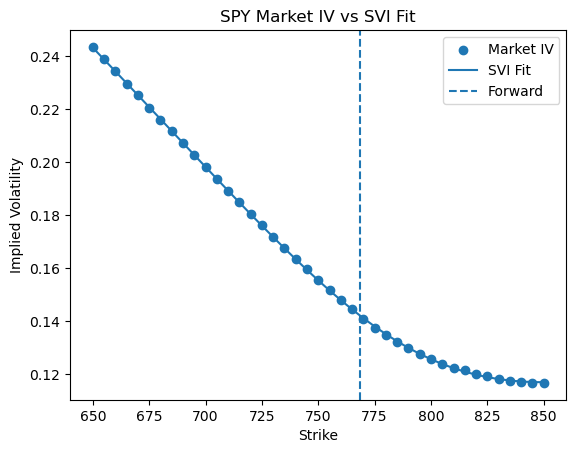

In [28]:
plt.scatter(
    smile["Strike"],
    smile["market_iv"],
    label="Market IV"
)

plt.plot(
    smile["Strike"],
    smile["svi_iv"],
    label="SVI Fit"
)

plt.axvline(
    forward,
    linestyle="--",
    label="Forward"
)

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("SPY Market IV vs SVI Fit")
plt.legend()

plt.show()

In [29]:
rmse = np.sqrt(
    np.mean(
        (smile["market_iv"] - smile["svi_iv"]) ** 2
    )
)

rmse

np.float64(0.00021303953509804619)

## 9. No-Arbitrage Diagnostics

In [30]:
# Evaluate SVI on a dense log-moneyness grid
k_grid = np.linspace(
    smile["log_moneyness"].min(),
    smile["log_moneyness"].max(),
    500
)

w_grid = svi(k_grid, a, b, rho, m, sigma)

print("Minimum fitted total variance:", w_grid.min())
print("All fitted total variances positive:", np.all(w_grid > 0))

Minimum fitted total variance: 0.004010490829340525
All fitted total variances positive: True


A low calibration RMSE does not by itself guarantee that the fitted smile is economically admissible. As a basic diagnostic, the fitted total variance is evaluated on a dense log-moneyness grid to verify that it remains positive across the calibrated strike range.

In [31]:
def svi_derivatives(k, a, b, rho, m, sigma):
    x = k - m
    root = np.sqrt(x**2 + sigma**2)

    w = a + b * (rho * x + root)

    w_prime = b * (
        rho + x / root
    )

    w_second = b * sigma**2 / root**3

    return w, w_prime, w_second

In [32]:
w, w_prime, w_second = svi_derivatives(
    k_grid, a, b, rho, m, sigma
)

g = (
    (1 - k_grid * w_prime / (2 * w))**2
    - (w_prime**2 / 4) * (1 / w + 0.25)
    + w_second / 2
)

print("Minimum g(k):", g.min())
print("Butterfly-arbitrage free on grid:", np.all(g >= 0))

Minimum g(k): 0.30196925999383634
Butterfly-arbitrage free on grid: True


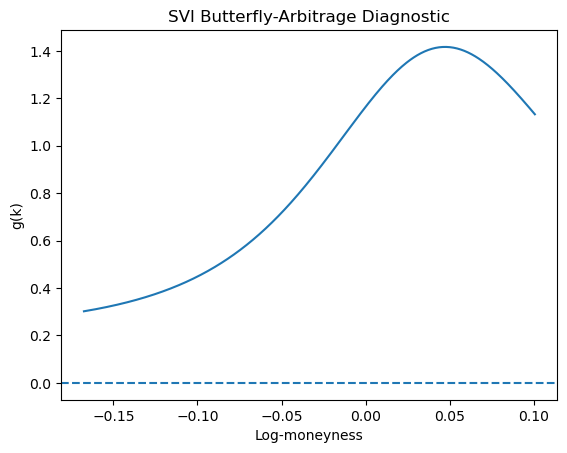

In [33]:
plt.plot(k_grid, g)
plt.axhline(0, linestyle="--")

plt.xlabel("Log-moneyness")
plt.ylabel("g(k)")
plt.title("SVI Butterfly-Arbitrage Diagnostic")

plt.show()

The fitted total variance remains positive across the calibrated log-moneyness range, and the butterfly-arbitrage diagnostic satisfies \(g(k) > 0\) throughout the evaluation grid. This indicates that the fitted SVI slice is locally free of butterfly arbitrage over the region considered.

## 10. Residual Diagnostics

Residuals are examined across strikes to identify any systematic regions where the fitted SVI curve differs from observed market implied volatility.

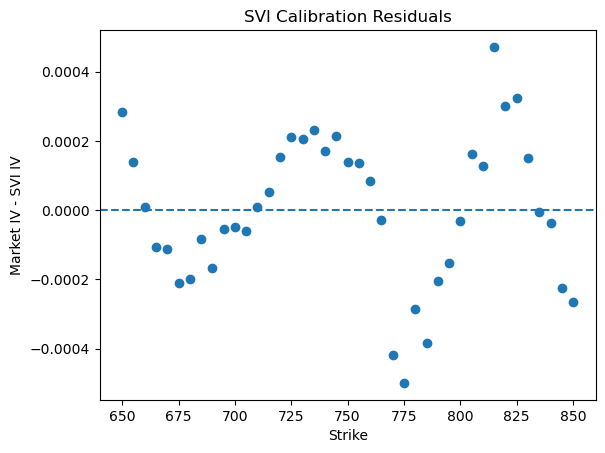

In [34]:
residuals_final = smile["market_iv"] - smile["svi_iv"]

plt.scatter(
    smile["Strike"],
    residuals_final
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Strike")
plt.ylabel("Market IV - SVI IV")
plt.title("SVI Calibration Residuals")

plt.show()

In [35]:
print(f"a     = {a:.6f}")
print(f"b     = {b:.6f}")
print(f"rho   = {rho:.6f}")
print(f"m     = {m:.6f}")
print(f"sigma = {sigma:.6f}")
print(f"RMSE  = {rmse:.6f}")

a     = -0.001664
b     = 0.058292
rho   = -0.572245
m     = 0.017535
sigma = 0.118705
RMSE  = 0.000213


## 11. Conclusion

The raw SVI model was calibrated to the 18 December 2026 SPY implied-volatility smile using constrained nonlinear least squares.

The forward price was estimated from near-at-the-money call and put prices using put-call parity, and the calibration used out-of-the-money puts below the forward and out-of-the-money calls above it.

The final calibration achieved an implied-volatility RMSE of approximately **0.000213**, with the fitted SVI curve closely tracking the observed market smile across the selected strike range.

The fitted negative value of \(\rho\) is consistent with the pronounced downside volatility skew observed in SPY options.

In addition to achieving a low calibration error, the fitted slice passes basic static-arbitrage diagnostics: total variance remains positive and the butterfly-arbitrage condition is satisfied across the calibrated moneyness range. This provides an economic validity check beyond statistical goodness of fit.